<a href="https://colab.research.google.com/github/etsub28/datascience/blob/main/financial_inclusion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
# dataframe + plotting
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# starter model (we may upgrade later)
from lightgbm import LGBMClassifier

# utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
train = pd.read_csv('/content/drive/MyDrive/Train.csv')
test = pd.read_csv('/content/drive/MyDrive/Test.csv')
sample = pd.read_csv('/content/drive/MyDrive/SampleSubmission.csv')

In [48]:
print('train data shape :', train.shape)
print('test data shape :', test.shape)

train data shape : (23524, 13)
test data shape : (10086, 12)


In [49]:
train.head()

,country,year,uniqueid,bank_account,location_type,cellphone_access,household_size,age_of_respondent,gender_of_respondent,relationship_with_head,marital_status,education_level,job_type
0,Kenya,2018,uniqueid_1,Yes,Rural,Yes,3,24,Female,Spouse,Married/Living together,Secondary education,Self employed
1,Kenya,2018,uniqueid_2,No,Rural,No,5,70,Female,Head of Household,Widowed,No formal education,Government Dependent
2,Kenya,2018,uniqueid_3,Yes,Urban,Yes,5,26,Male,Other relative,Single/Never Married,Vocational/Specialised training,Self employed
3,Kenya,2018,uniqueid_4,No,Rural,Yes,5,34,Female,Head of Household,Married/Living together,Primary education,Formally employed Private
4,Kenya,2018,uniqueid_5,No,Urban,No,8,26,Male,Child,Single/Never Married,Primary education,Informally employed


In [50]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23524 entries, 0 to 23523
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   country                 23524 non-null  object
 1   year                    23524 non-null  int64 
 2   uniqueid                23524 non-null  object
 3   bank_account            23524 non-null  object
 4   location_type           23524 non-null  object
 5   cellphone_access        23524 non-null  object
 6   household_size          23524 non-null  int64 
 7   age_of_respondent       23524 non-null  int64 
 8   gender_of_respondent    23524 non-null  object
 9   relationship_with_head  23524 non-null  object
 10  marital_status          23524 non-null  object
 11  education_level         23524 non-null  object
 12  job_type                23524 non-null  object
dtypes: int64(3), object(10)
memory usage: 2.3+ MB


In [51]:
print(train.isnull().sum())

country                   0
year                      0
uniqueid                  0
bank_account              0
location_type             0
cellphone_access          0
household_size            0
age_of_respondent         0
gender_of_respondent      0
relationship_with_head    0
marital_status            0
education_level           0
job_type                  0
dtype: int64


In [52]:
train['bank_account'].value_counts()

,count
bank_account,
No,20212
Yes,3312


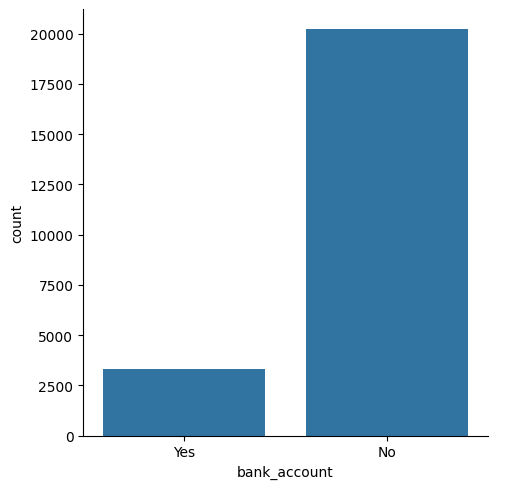

In [53]:
sns.catplot(
    x="bank_account",
    kind="count",
    data=train
);

In [54]:
sample.head()

,unique_id,bank_account
0,uniqueid_1 x Kenya,0
1,uniqueid_2 x Kenya,0
2,uniqueid_3 x Kenya,0
3,uniqueid_4 x Kenya,0
4,uniqueid_5 x Kenya,0


In [55]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train["bank_account"] = le.fit_transform(
    train["bank_account"]
)

In [56]:
def preprocessing_data(data):

    data = data.copy()

    # engineered features
    data["age_house_ratio"] = (
        data["age_of_respondent"] /
        (data["household_size"] + 1)
    )

    data["age_house_interaction"] = (
        data["age_of_respondent"] *
        data["household_size"]
    )

    data["is_young"] = (
        data["age_of_respondent"] < 30
    ).astype(int)

    data["large_household"] = (
        data["household_size"] >= 5
    ).astype(int)

    # age bins
    data["age_bin"] = pd.cut(
        data["age_of_respondent"],
        bins=[15,25,35,50,100],
        labels=[
            "young",
            "adult",
            "mid",
            "senior"
        ]
    )

    # one-hot categorical
    categ = [
        "relationship_with_head",
        "marital_status",
        "education_level",
        "job_type",
        "country",
        "age_bin"
    ]

    data = pd.get_dummies(
        data,
        columns=categ
    )

    # label encoding binary categories
    for col in [
        "location_type",
        "cellphone_access",
        "gender_of_respondent"
    ]:
        data[col] = LabelEncoder().fit_transform(
            data[col]
        )

    # remove id
    data = data.drop(
        ["uniqueid"],
        axis=1
    )

    return data

In [57]:
X_train = train.drop(
    ["bank_account"],
    axis=1
)

y_train = train["bank_account"]

processed_train = preprocessing_data(
    X_train
)

processed_test = preprocessing_data(
    test
)

In [58]:
print(processed_train.shape)
print(processed_test.shape)

(23524, 45)
(10086, 45)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val = train_test_split(
    processed_train,
    y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=42
)

In [60]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    gamma=1,
    random_state=42,
    eval_metric='logloss'
)

In [61]:
xgb_model.fit(X_train, y_train_split)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
from sklearn.metrics import accuracy_score

val_preds = xgb_model.predict(X_val)

error_rate = 1 - accuracy_score(y_val, val_preds)

print("Validation Error Rate:", error_rate)

Validation Error Rate: 0.10964725881852955


In [63]:
test.bank_account = xgb_model.predict(processed_test)

In [64]:
# Create submission DataFrame
submission = pd.DataFrame({
    "uniqueid": test["uniqueid"] + " x " + test["country"],
    "bank_account": test.bank_account
})


In [65]:
# show sample
submission.sample(5)

,uniqueid,bank_account
4657,uniqueid_10792 x Rwanda,0
7770,uniqueid_8045 x Tanzania,0
3787,uniqueid_9922 x Rwanda,0
8108,uniqueid_8383 x Tanzania,0
9619,uniqueid_2536 x Uganda,0


In [66]:
# Create submission csv file
submission.to_csv('fosubmission.csv', index=False)

# download file (Google Colab)
from google.colab import files
files.download('fosubmission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>